In [1]:
from ravex import MultiPlanetSystem, carm_error, maroonx_serval_error
import numpy as np
import astropy.units as u
import astropy.time as t
import matplotlib.pyplot as plt

In [2]:
# Define the host star mass
mass_star = 0.62 * u.solMass

# Define a single planet
planet1 = {
    "mass": 4.6 * u.earthMass,
    "time_periastron": t.Time("2019-11-30T04:23:05.000", format="isot", scale="utc"),
    "inclination": 90.0 * u.deg,
    "argument_periapse": 90.0 * u.deg,
    "eccentricity": 0.0,
    "orbital_period": 13.47 * u.day,
}

# Build the planetary system
system = MultiPlanetSystem(mass_star, [planet1])

In [3]:
# Build a dense and regular time grid over the same observing baseline
n_model = 10000
# Define the observing baseline
start_time = t.Time("2020-01-01T00:00:00", format="isot", scale="utc")
span_days = 100

time_grid = t.Time(
    start_time.jd + np.linspace(0, span_days, n_model),
    format="jd",
    scale="utc"
)

# Compute the noiseless RV model
jd_model, rv_model, phases_model, phased_model = system.get_rvs(time_grid)

In [4]:
rv_max = np.max(rv_model)
rv_min = np.min(rv_model)
K_est = 0.5 * (rv_max - rv_min)

print(f"Estimated semi-amplitude K: {K_est:.3f} m/s")

Estimated semi-amplitude K: 1.700 m/s


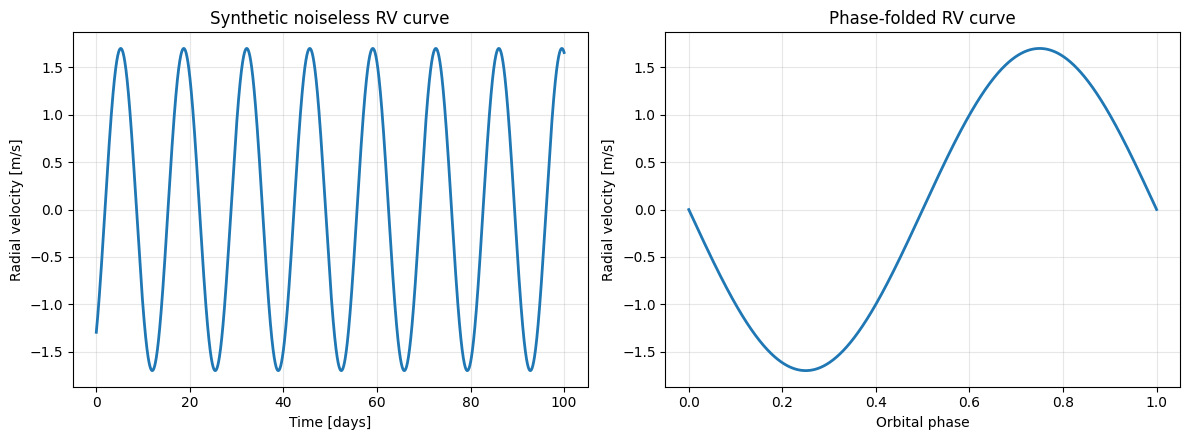

In [5]:
# Plot the theoretical noiseless RV curve in time and phase
time_days = jd_model - jd_model[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left panel: RV as a function of time
axes[0].plot(time_days, rv_model, lw=2)
axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel("Radial velocity [m/s]")
axes[0].set_title("Synthetic noiseless RV curve")
axes[0].grid(alpha=0.3)

# Right panel: RV as a function of orbital phase
axes[1].plot(phased_model["p0"]["phase"], phased_model["p0"]["rv"], lw=2)
axes[1].set_xlabel("Orbital phase")
axes[1].set_ylabel("Radial velocity [m/s]")
axes[1].set_title("Phase-folded RV curve")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
# Estimate the instrumental RV uncertainty for this target assuming CARMENES observations
sigma_carm = carm_error(
    jmag=7.37,
    spt=0.5,
    vsini=1.5
)

# Assume an additional astrophysical jitter term
sigma_jitter = 2.0  # m/s

# Total per-measurement uncertainty
sigma_eff = np.sqrt(sigma_carm**2 + sigma_jitter**2)

print(f"CARMENES-like instrumental error: {sigma_carm:.3f} m/s")
print(f"Assumed stellar jitter: {sigma_jitter:.3f} m/s")
print(f"Total RV uncertainty per measurement: {sigma_eff:.3f} m/s")

CARMENES-like instrumental error: 1.573 m/s
Assumed stellar jitter: 2.000 m/s
Total RV uncertainty per measurement: 2.544 m/s


In [7]:
# Simulate discrete RV observations with noise
n_obs = 30
start_time = t.Time("2020-01-01T00:00:00", format="isot", scale="utc")

rng = np.random.default_rng(42)

observation_dates = system.obs_dates(
    n_obs=n_obs,
    span_days=span_days,
    date_one=start_time,
    rng=rng
)

jd_sim, rv_sim, phases_sim, phased_sim = system.get_rvs(
    observation_dates,
    noise=sigma_eff * u.m / u.s,
    rng=np.random.default_rng(45)
)

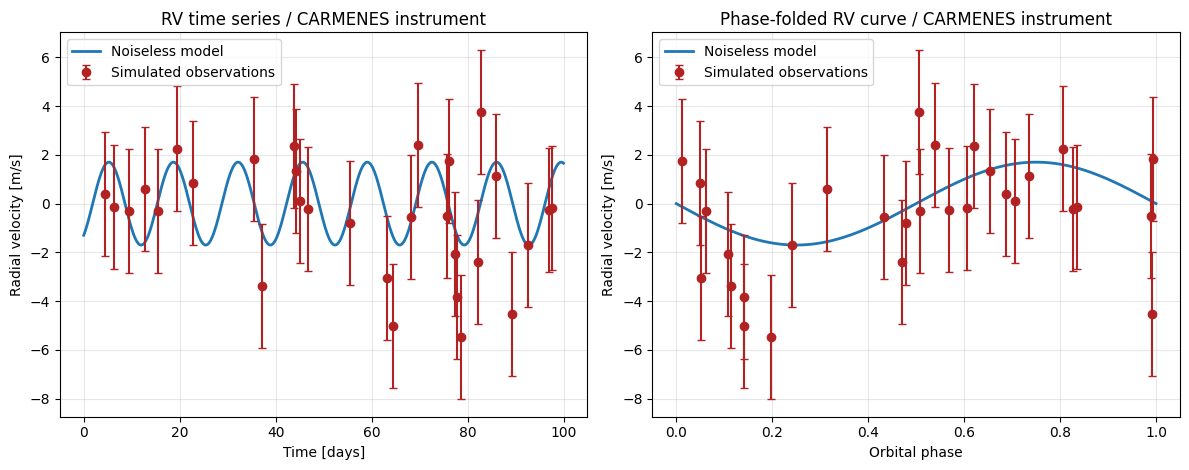

In [8]:
# Plot the noiseless model and the simulated RV observations in time and phase
time_model_days = jd_model - jd_model[0]
time_sim_days = jd_sim - jd_model[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Left panel: time series
axes[0].plot(time_model_days, rv_model, lw=2, label="Noiseless model")
axes[0].errorbar(
    time_sim_days,
    rv_sim,
    yerr=sigma_eff,
    fmt="o",
    capsize=3,
    color="firebrick",
    label="Simulated observations"
)
axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel("Radial velocity [m/s]")
axes[0].set_title("RV time series / CARMENES instrument")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right panel: phase-folded curve
axes[1].plot(phased_model["p0"]["phase"], phased_model["p0"]["rv"], lw=2, label="Noiseless model")
axes[1].errorbar(
    phased_sim["p0"]["phase"],
    phased_sim["p0"]["rv"],
    yerr=sigma_eff,
    fmt="o",
    capsize=3,
    color="firebrick",
    label="Simulated observations"
)
axes[1].set_xlabel("Orbital phase")
axes[1].set_ylabel("Radial velocity [m/s]")
axes[1].set_title("Phase-folded RV curve / CARMENES instrument")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# MAROON-X input from the ETC
snr_peak_red = 631   # example value from the ETC
snr_peak_blue = 389   # example value from the ETC

arm1 = "red"
arm2 = "blue"

# Estimated intrinsic SERVAL RV uncertainty for MAROON-X
sigma_maroonx_red = maroonx_serval_error(
    snr_peak=snr_peak_red,
    spectral_type="K8",    
    arm=arm1
)

sigma_maroonx_blue = maroonx_serval_error(
    snr_peak=snr_peak_blue,
    spectral_type="K8",    
    arm=arm2
)

# Assumed stellar jitter
sigma_jitter = 1.0  # m/s

# Total per-measurement uncertainty
sigma_eff_maroonx_red = np.sqrt(sigma_maroonx_red**2 + sigma_jitter**2)
sigma_eff_maroonx_blue = np.sqrt(sigma_maroonx_blue**2 + sigma_jitter**2)


print(f"MAROON-X ({arm1} arm) instrumental error: {sigma_maroonx_red:.3f} m/s")
print(f"Assumed stellar jitter: {sigma_jitter:.3f} m/s")
print(f"Total RV uncertainty per measurement: {sigma_eff_maroonx_red:.3f} m/s")
print("**********")
print(f"MAROON-X ({arm2} arm) instrumental error: {sigma_maroonx_blue:.3f} m/s")
print(f"Assumed stellar jitter: {sigma_jitter:.3f} m/s")
print(f"Total RV uncertainty per measurement: {sigma_eff_maroonx_blue:.3f} m/s")

MAROON-X (red arm) instrumental error: 0.381 m/s
Assumed stellar jitter: 1.000 m/s
Total RV uncertainty per measurement: 1.070 m/s
**********
MAROON-X (blue arm) instrumental error: 0.266 m/s
Assumed stellar jitter: 1.000 m/s
Total RV uncertainty per measurement: 1.035 m/s


In [13]:
# Simulate discrete RV observations with noise
n_obs = 30
start_time = t.Time("2020-01-01T00:00:00", format="isot", scale="utc")

rng = np.random.default_rng(42)

observation_dates = system.obs_dates(
    n_obs=n_obs,
    span_days=span_days,
    date_one=start_time,
    rng=rng
)

jd_sim_red, rv_sim_red, phases_sim_red, phased_sim_red = system.get_rvs(
    observation_dates,
    noise=sigma_eff_maroonx_red * u.m / u.s,
    rng=np.random.default_rng(42)
)

jd_sim_blue, rv_sim_blue, phases_sim_blue, phased_sim_blue = system.get_rvs(
    observation_dates,
    noise=sigma_eff_maroonx_blue * u.m / u.s,
    rng=np.random.default_rng(43)
)

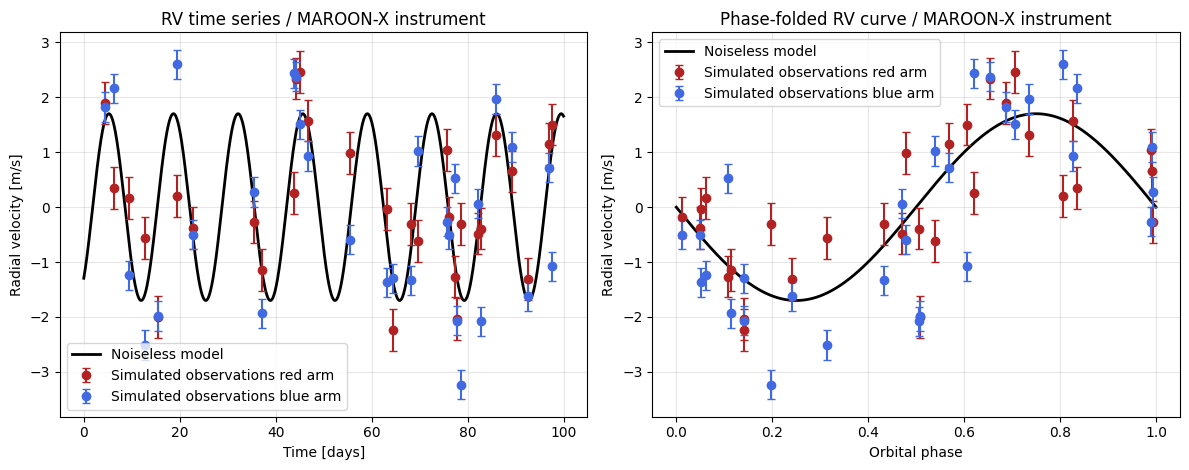

In [14]:
# Plot the noiseless model and the simulated RV observations in time and phase
time_model_days = jd_model - jd_model[0]
time_sim_days_red = jd_sim_red - jd_model[0]
time_sim_days_blue = jd_sim_blue - jd_model[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Left panel: time series
axes[0].plot(time_model_days, rv_model, lw=2, color='black',label="Noiseless model")
axes[0].errorbar(
    time_sim_days_red,
    rv_sim_red,
    yerr=sigma_maroonx_red,
    fmt="o",
    capsize=3,
    color="firebrick",
    label="Simulated observations red arm"
)

axes[0].errorbar(
    time_sim_days_blue,
    rv_sim_blue,
    yerr=sigma_maroonx_blue,
    fmt="o",
    capsize=3,
    color="royalblue",
    label="Simulated observations blue arm"
)

axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel("Radial velocity [m/s]")
axes[0].set_title("RV time series / MAROON-X instrument")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right panel: phase-folded curve
axes[1].plot(phased_model["p0"]["phase"], phased_model["p0"]["rv"], lw=2, color='black',label="Noiseless model")

axes[1].errorbar(
    phased_sim_red["p0"]["phase"],
    phased_sim_red["p0"]["rv"],
    yerr=sigma_maroonx_red,
    fmt="o",
    capsize=3,
    color="firebrick",
    label="Simulated observations red arm"
)

axes[1].errorbar(
    phased_sim_blue["p0"]["phase"],
    phased_sim_blue["p0"]["rv"],
    yerr=sigma_maroonx_blue,
    fmt="o",
    capsize=3,
    color="royalblue",
    label="Simulated observations blue arm"
)

axes[1].set_xlabel("Orbital phase")
axes[1].set_ylabel("Radial velocity [m/s]")
axes[1].set_title("Phase-folded RV curve / MAROON-X instrument")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()